# 1. Introduction
This notebook performs an initial exploratory data analysis (EDA) for the Telco Customer Churn dataset. 
The goal is to understand the data, identify potential issues, and establish a baseline for modeling.


In [15]:
# Manipulación de datos
import pandas as pd
import numpy as np
import math

# Configuración del sistema
import sys
from pathlib import Path

ROOT_DIR = Path().resolve().parent
sys.path.append(str(ROOT_DIR))


# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno  # Visualización de valores faltantes
import matplotlib.pyplot as plt


# Estadísticas y métricas
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Modelado rápido para baseline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, recall_score, confusion_matrix, classification_report



# 2. Data Loading
Load the dataset from the raw data directory and inspect basic information.


In [16]:
# Carga el dataset 
df = pd.read_csv(r"C:\Users\diego\Documents\Analisis\churn-ml-system\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv")
# Muestra información básica del dataset
df.info()
df.describe()

df.head().style.set_table_attributes("style='display:inline'").set_caption('First 5 rows of the dataset')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850000,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950000,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850000,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300000,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700000,151.65,Yes


# 3. Initial Data Inspection
Check the first rows, data types, basic statistics, and missing values.


## Feature Types Summary

| Feature | Variable Type | Notes |
|--------|---------------|-------|
| `customerID` | Identifier (ID) | Unique identifier, excluded from analysis and modeling |
| `gender` | Categorical (binary, nominal) | Male / Female |
| `SeniorCitizen` | Binary (0/1, categorical) | Treated as categorical despite numeric encoding |
| `Partner` | Categorical (binary) | Yes / No |
| `Dependents` | Categorical (binary) | Yes / No |
| `tenure` | Numerical (discrete) | Number of months as a customer |
| `PhoneService` | Categorical (binary) | Yes / No |
| `MultipleLines` | Categorical (nominal) | Yes / No / No phone service |
| `InternetService` | Categorical (nominal) | DSL / Fiber optic / No |
| `OnlineSecurity` | Categorical (nominal) | Yes / No / No internet service |
| `OnlineBackup` | Categorical (nominal) | Yes / No / No internet service |
| `DeviceProtection` | Categorical (nominal) | Yes / No / No internet service |
| `TechSupport` | Categorical (nominal) | Yes / No / No internet service |
| `StreamingTV` | Categorical (nominal) | Yes / No / No internet service |
| `StreamingMovies` | Categorical (nominal) | Yes / No / No internet service |
| `Contract` | Categorical (ordinal) | Month-to-month < One year < Two year |
| `PaperlessBilling` | Categorical (binary) | Yes / No |
| `PaymentMethod` | Categorical (nominal) | Four different payment methods |
| `MonthlyCharges` | Numerical (continuous) | Monthly customer charges |
| `TotalCharges` | Numerical (continuous) | Total accumulated charges |
| `Churn` | Binary (target variable) | Customer churn indicator |



In [17]:
#Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)

#checking for duplicates in the dataset
df.duplicated().sum()

Missing values in each column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


np.int64(0)

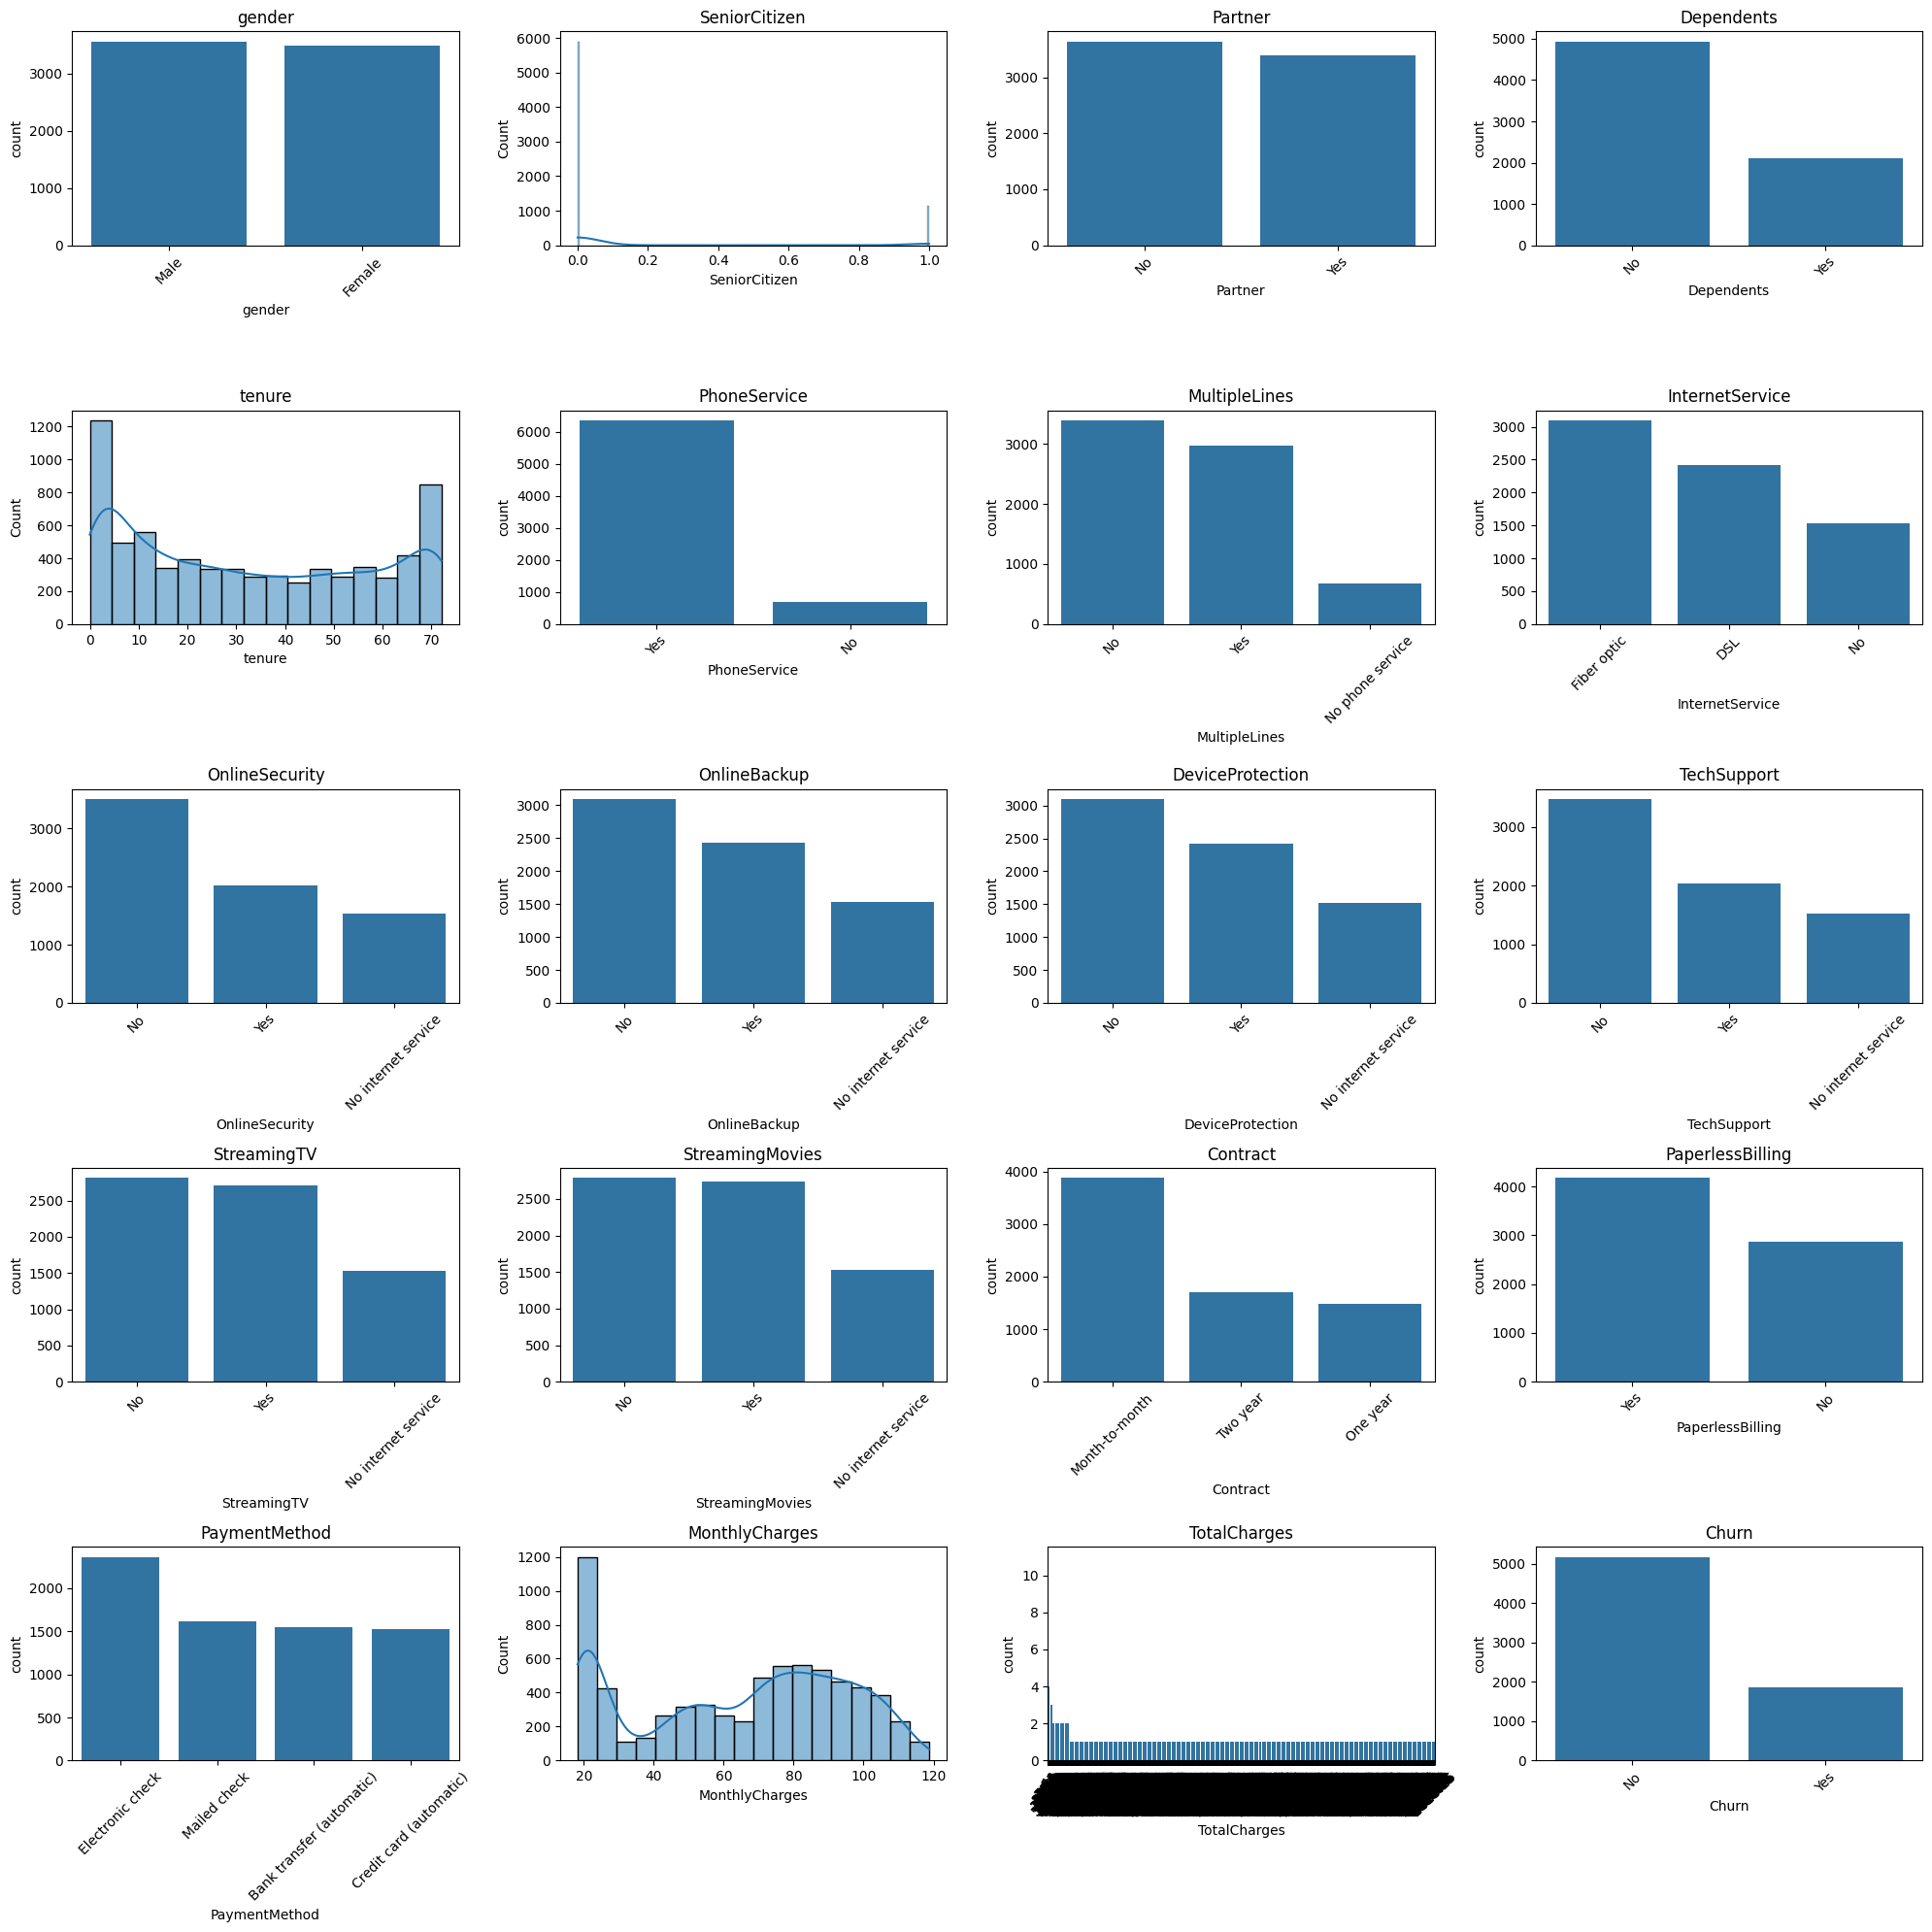

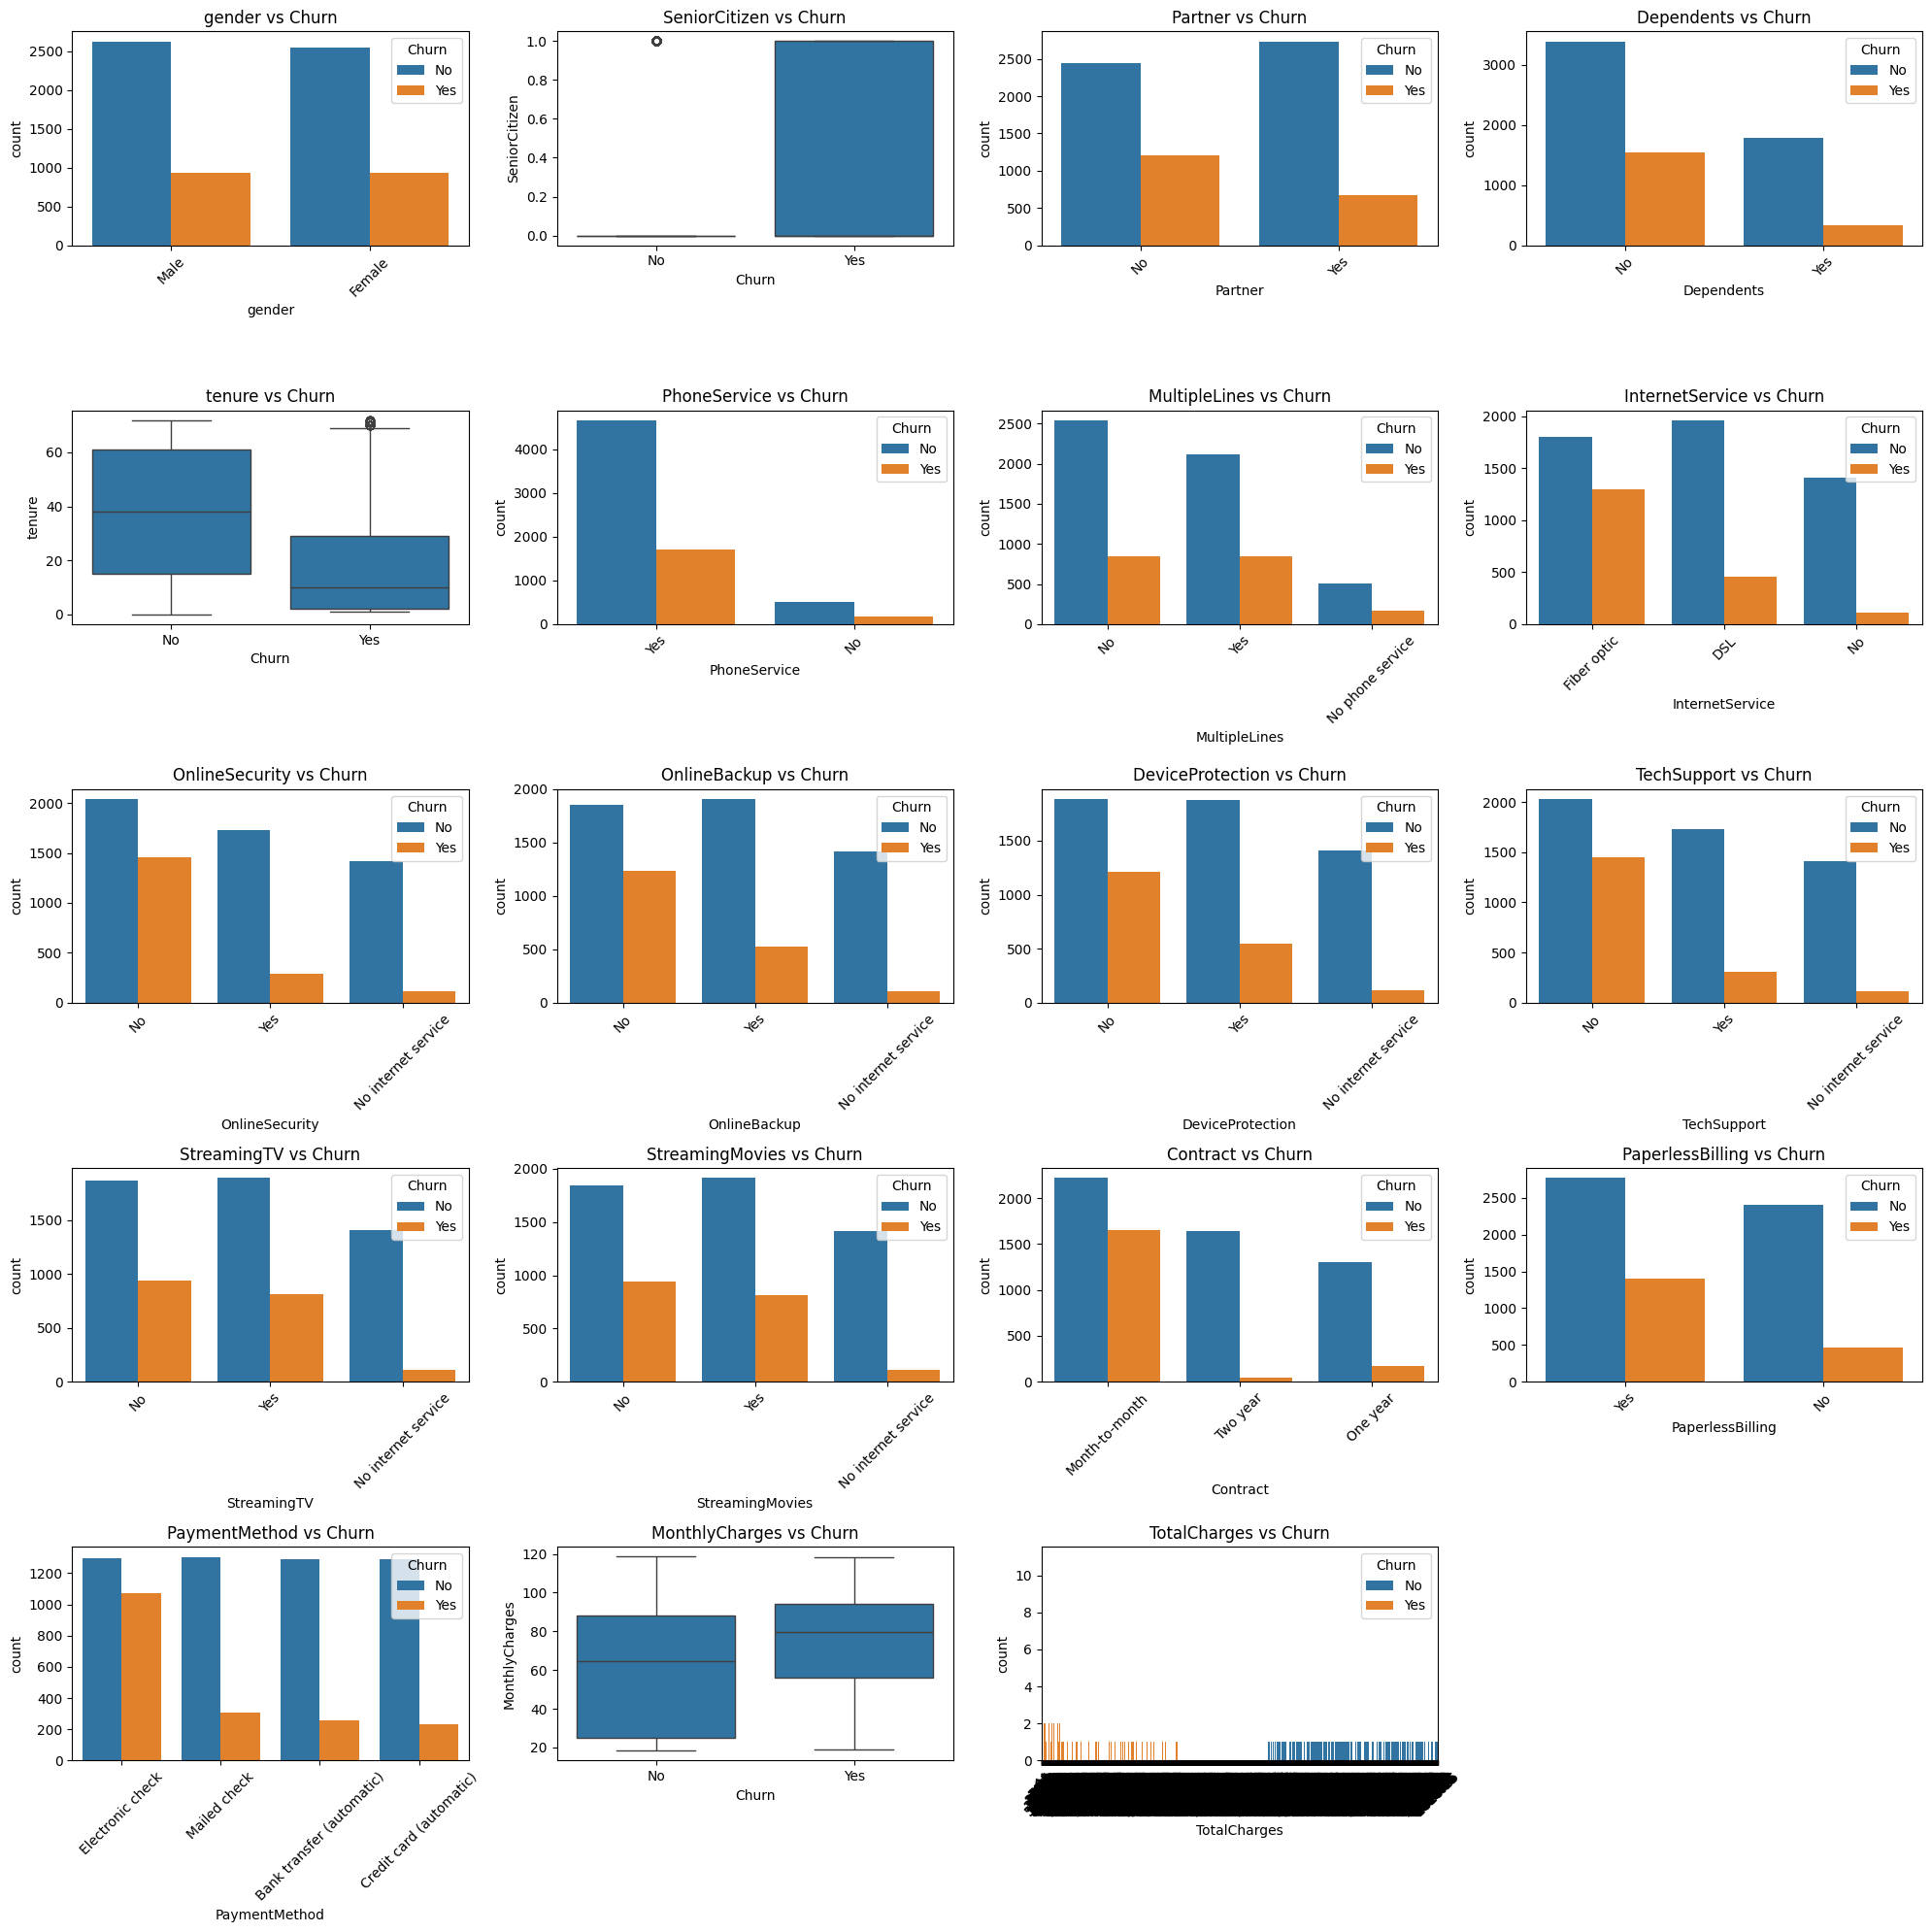

In [18]:
from src.eda.visualization import plot_eda_grid, plot_eda_grid_vs_target
features = df.columns.tolist()

plot_eda_grid(df, features, cols=4)
plot_eda_grid_vs_target(df, features, target='Churn', cols=4)